# Part 2 - Computer Vision - Manufacturing Defect CNN

# Task 1 - Problem Identification

**Problem type - Multi-Class Image Classification**

Each product image belongs to one of four categories — normal, scratch, dent, or stain. There's no ambiguity; a surface either has a scratch or it doesn't. We're not trying to draw boxes around defects or map out exactly which pixels are damaged. We just need to look at the image and say "this one's a scratch" or "this one's fine." That's classification in its simplest form.
Compare this to object detection, where you'd need to mark where in the image the defect appears, or segmentation, where you'd color in every affected pixel. Both of those would be overkill here — the factory just needs to know what kind of defect it's looking at, not a pixel-perfect map of it.
So image classification is the right tool: one image goes in, one label comes out. Clean, efficient, and exactly what the problem calls for.



In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings; warnings.filterwarnings('ignore')
import os; os.environ['IF_CPP_MIN_LOG_LEVEL'] = '3'

tf.random.set_seed(0)
np.random.seed(0)
print("Tensorflow:", tf.__version__)
print("All imports successful!")

Tensorflow: 2.21.0
All imports successful!


# Task 2: Dataset Exploration

In [2]:
import os
print(os.getcwd())

c:\Users\ACER\Desktop


In [3]:
CLASSES = ['normal', 'scratch', 'dent', 'stain']
CLASS_COLORS = {'normal': 'green', 'scratch': 'red',
                'dent': 'blue', 'stain': 'yellow'}
IMG_DIR = 'images'

counts = {cls: len(os.listdir(f'{IMG_DIR}/{cls}')) for cls in CLASSES} # Count images per class
total = sum(counts.values())

print("=" * 40)
print("DATASET SUMMARY")
print("=" * 40)
print(f"Total images  : {total}")
print(f"Classes       : {CLASSES}")
for cls, n in counts.items():
    print(f"  {cls:10s}: {n} images ({n/total*100:.1f}%)")

sample = Image.open(f'{IMG_DIR}/normal/normal_001.png')
print(f"Image shape   : {sample.size[0]} x {sample.size[1]} x 3 (RGB)")
print(f"Balance       : PERFECTLY BALANCED (no class imbalance)")

DATASET SUMMARY
Total images  : 480
Classes       : ['normal', 'scratch', 'dent', 'stain']
  normal    : 120 images (25.0%)
  scratch   : 120 images (25.0%)
  dent      : 120 images (25.0%)
  stain     : 120 images (25.0%)
Image shape   : 96 x 96 x 3 (RGB)
Balance       : PERFECTLY BALANCED (no class imbalance)


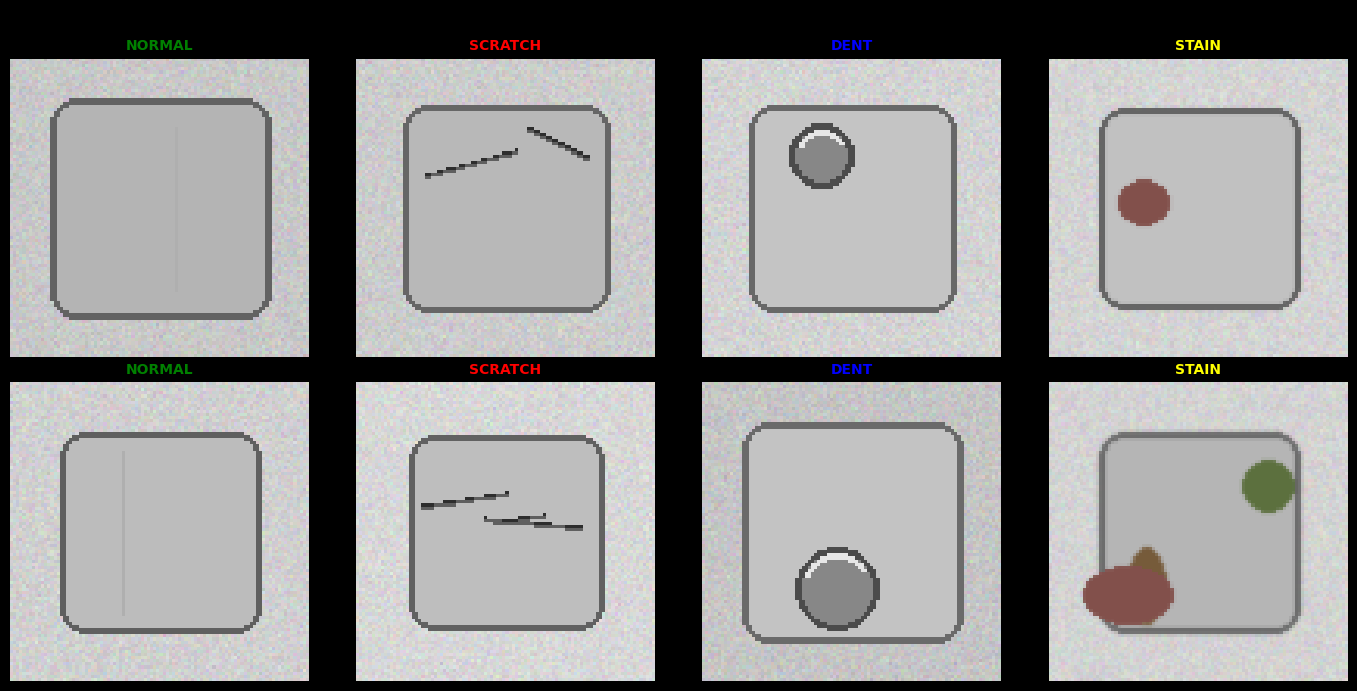

Saved: results/dataset_exploration.png


In [4]:
# Visualize sample images from each class

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Sample Images from Each Class (2 per class)', fontsize=13, fontweight='bold')
fig.patch.set_facecolor('black')

for ci, cls in enumerate(CLASSES):
    files = sorted(os.listdir(f'{IMG_DIR}/{cls}'))[:2]
    for j, fname in enumerate(files):
        ax = axes[j, ci]
        img = Image.open(f'{IMG_DIR}/{cls}/{fname}')
        ax.imshow(np.array(img))
        ax.set_title(f'{cls.upper()}', color=CLASS_COLORS[cls], fontsize=10, fontweight='bold')
        ax.axis('off')
        for sp in ax.spines.values():
            sp.set_edgecolor(CLASS_COLORS[cls]); sp.set_linewidth(2.5)

plt.tight_layout()
plt.savefig('results/dataset_exploration.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("Saved: results/dataset_exploration.png")

## Task 3: Image Preprocessing

In [5]:
IMG_SIZE = 64  # Resize all images to 64x64

# Load and normalize all images
X, y = [], []
for label_idx, cls in enumerate(CLASSES):
    for fname in sorted(os.listdir(f'{IMG_DIR}/{cls}')):
        if fname.endswith('.png'):
            img = Image.open(f'{IMG_DIR}/{cls}/{fname}').convert('RGB')
            img = img.resize((IMG_SIZE, IMG_SIZE))     # Resize
            X.append(np.array(img))
            y.append(label_idx)

X = np.array(X, dtype=np.float32) / 255.0             # Normalize: [0,255] -> [0.0,1.0]
y = np.array(y)

print(f"X shape      : {X.shape}   (samples, height, width, channels)")
print(f"y shape      : {y.shape}")
print(f"Pixel range  : [{X.min():.1f}, {X.max():.1f}]  (after normalization)")

# Stratified split: 70% train, 10% val, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=0)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.125, stratify=y_train, random_state=0)

print(f"\nDataset split (stratified):")
print(f"  Train : {len(X_train):4d} images ({len(X_train)/len(X)*100:.0f}%)")
print(f"  Val   : {len(X_val):4d} images ({len(X_val)/len(X)*100:.0f}%)")
print(f"  Test  : {len(X_test):4d} images ({len(X_test)/len(X)*100:.0f}%)")

# tf.data pipelines
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(400).batch(32).prefetch(1)
val_ds   = tf.data.Dataset.from_tensor_slices((X_val,   y_val  )).batch(32)
test_ds  = tf.data.Dataset.from_tensor_slices((X_test,  y_test )).batch(32)


X shape      : (480, 64, 64, 3)   (samples, height, width, channels)
y shape      : (480,)
Pixel range  : [0.1, 1.0]  (after normalization)

Dataset split (stratified):
  Train :  336 images (70%)
  Val   :   48 images (10%)
  Test  :   96 images (20%)


# Task 4: CNN Model Architecture

In [6]:
model = keras.Sequential([
    keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # ── Convolutional Block 1 ──────────────────────────────────────
    layers.Conv2D(16, 3, padding='same', activation='relu', name='conv1'),
    # ReLU: max(0,x) — introduces non-linearity, avoids vanishing gradients
    layers.MaxPooling2D(2, name='pool1'),
    # MaxPool: halves spatial size, provides translation invariance

    # ── Convolutional Block 2 ──────────────────────────────────────
    layers.Conv2D(32, 3, padding='same', activation='relu', name='conv2'),
    layers.MaxPooling2D(2, name='pool2'),

    # ── Convolutional Block 3 ──────────────────────────────────────
    layers.Conv2D(64, 3, padding='same', activation='relu', name='conv3'),
    layers.MaxPooling2D(2, name='pool3'),

    # ── Classification Head ────────────────────────────────────────
    layers.Flatten(),                        # 8x8x64 = 4096 features
    layers.Dense(64, activation='relu'),     # Learn high-level combinations
    layers.Dropout(0.3),                     # Regularization: prevent overfitting
    layers.Dense(4, activation='softmax'),   # 4 class probabilities (sum to 1)

], name='ManufacturingDefectCNN')

model.summary()

Model: "ManufacturingDefectCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 286,052 (1.09 MB)

 Trainable params: 286,052 (1.09 MB)

 Non-trainable params: 0 (0.00 B)

# Task 5: Model Training and Evaluation

In [7]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5, verbose=0),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=10,
                                   restore_best_weights=True, verbose=1),
]

print("Training started...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=60,
    callbacks=callbacks,
    verbose=1
)
print("Training complete!")

Training started...
Epoch 1/60
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.2321 - loss: 1.3914 - val_accuracy: 0.2917 - val_loss: 1.3860 - learning_rate: 3.0000e-04
Epoch 2/60
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2411 - loss: 1.3952 - val_accuracy: 0.2500 - val_loss: 1.3824 - learning_rate: 3.0000e-04
Epoch 3/60
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2500 - loss: 1.3838 - val_accuracy: 0.2708 - val_loss: 1.3775 - learning_rate: 3.0000e-04
Epoch 4/60
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3095 - loss: 1.3742 - val_accuracy: 0.2917 - val_loss: 1.3694 - learning_rate: 3.0000e-04
Epoch 5/60
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3482 - loss: 1.3610 - val_accuracy: 0.2708 - val_loss: 1.3500 - learning_rate: 3.0000e-04
Epoch 6/60
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4018 - loss: 1.3329 - val_accuracy: 0.2708 - val_loss: 1.3174 - learning_rate: 3.0000e-04
Epoch 7/60
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

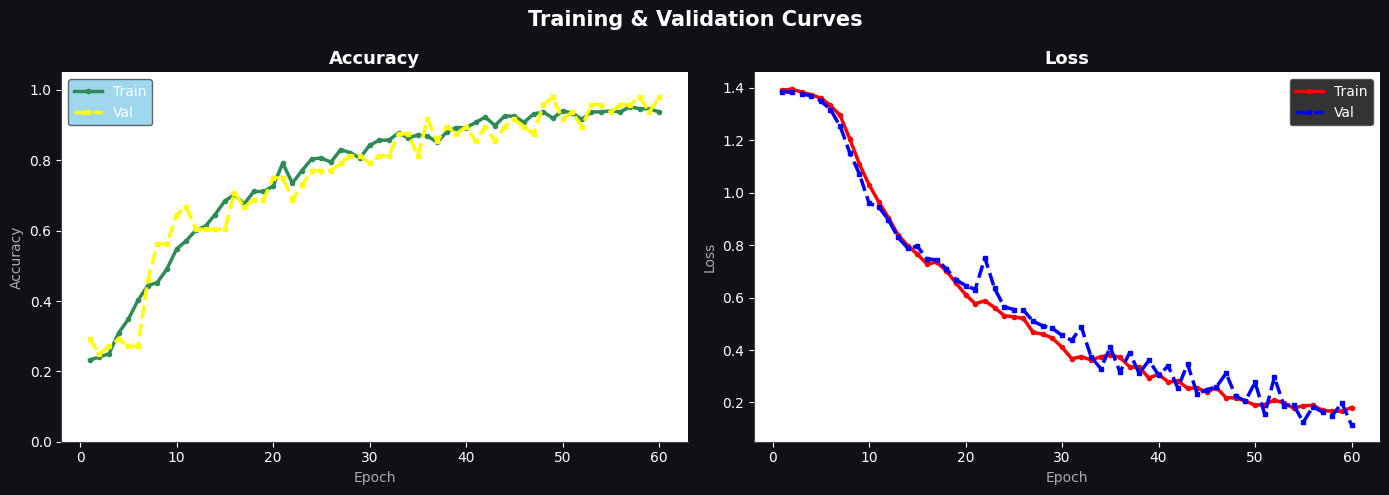

Saved: results/accuracy_loss_curves.png


In [12]:
# ── Training Curves ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f1117')

for ax in axes:
    ax.set_facecolor('white')
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['bottom','left']].set_color('#444')
    ax.tick_params(colors='white')

ep = range(1, len(history.history['accuracy']) + 1)

axes[0].plot(ep, history.history['accuracy'],     color='seagreen', lw=2.5, label='Train', marker='o', ms=3)
axes[0].plot(ep, history.history['val_accuracy'], color='yellow', lw=2.5, label='Val',   linestyle='--', marker='s', ms=3)
axes[0].set_title('Accuracy', color='white', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch', color='#aaa'); axes[0].set_ylabel('Accuracy', color='#aaa')
axes[0].legend(facecolor='skyblue', edgecolor='#444', labelcolor='white')
axes[0].set_ylim(0, 1.05)

axes[1].plot(ep, history.history['loss'],     color='red', lw=2.5, label='Train', marker='o', ms=3)
axes[1].plot(ep, history.history['val_loss'], color='blue', lw=2.5, label='Val',   linestyle='--', marker='s', ms=3)
axes[1].set_title('Loss', color='white', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch', color='#aaa'); axes[1].set_ylabel('Loss', color='#aaa')
axes[1].legend(facecolor='black', edgecolor='#444', labelcolor='white')

plt.suptitle('Training & Validation Curves', color='white', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('results/accuracy_loss_curves.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()
print("Saved: results/accuracy_loss_curves.png")

In [9]:
# ── Test Evaluation ──────────────────────────────────────────────────────────
y_prob = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
test_loss, test_acc = model.evaluate(test_ds, verbose=0)

print(f"{'='*45}")
print(f"  FINAL TEST RESULTS")
print(f"{'='*45}")
print(f"  Test Accuracy : {test_acc*100:.2f}%")
print(f"  Test Loss     : {test_loss:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=CLASSES))

  FINAL TEST RESULTS
  Test Accuracy : 92.71%
  Test Loss     : 0.2471

              precision    recall  f1-score   support

      normal       0.89      1.00      0.94        24
     scratch       0.91      0.88      0.89        24
        dent       0.92      0.92      0.92        24
       stain       1.00      0.92      0.96        24

    accuracy                           0.93        96
   macro avg       0.93      0.93      0.93        96
weighted avg       0.93      0.93      0.93        96



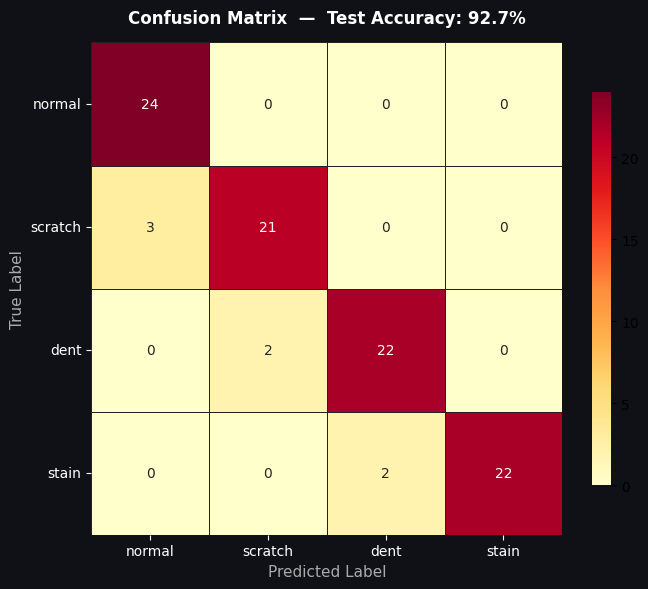

Saved: results/confusion_matrix.png


In [10]:
# ── Confusion Matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor('#0f1117')
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=CLASSES, yticklabels=CLASSES,
            ax=ax, linewidths=0.5, linecolor='#222', cbar_kws={'shrink': 0.8})
ax.set_facecolor('#1a1d27')
ax.set_title(f'Confusion Matrix  —  Test Accuracy: {test_acc*100:.1f}%',
             color='white', fontsize=12, fontweight='bold', pad=14)
ax.set_xlabel('Predicted Label', color='#aaa', fontsize=11)
ax.set_ylabel('True Label', color='#aaa', fontsize=11)
ax.tick_params(colors='white', labelsize=10)
plt.setp(ax.get_xticklabels(), color='white')
plt.setp(ax.get_yticklabels(), color='white', rotation=0)

plt.tight_layout()
plt.savefig('results/confusion_matrix.png', dpi=150, bbox_inches='tight', facecolor='black')
plt.show()
print("Saved: results/confusion_matrix.png")

Folders ready!


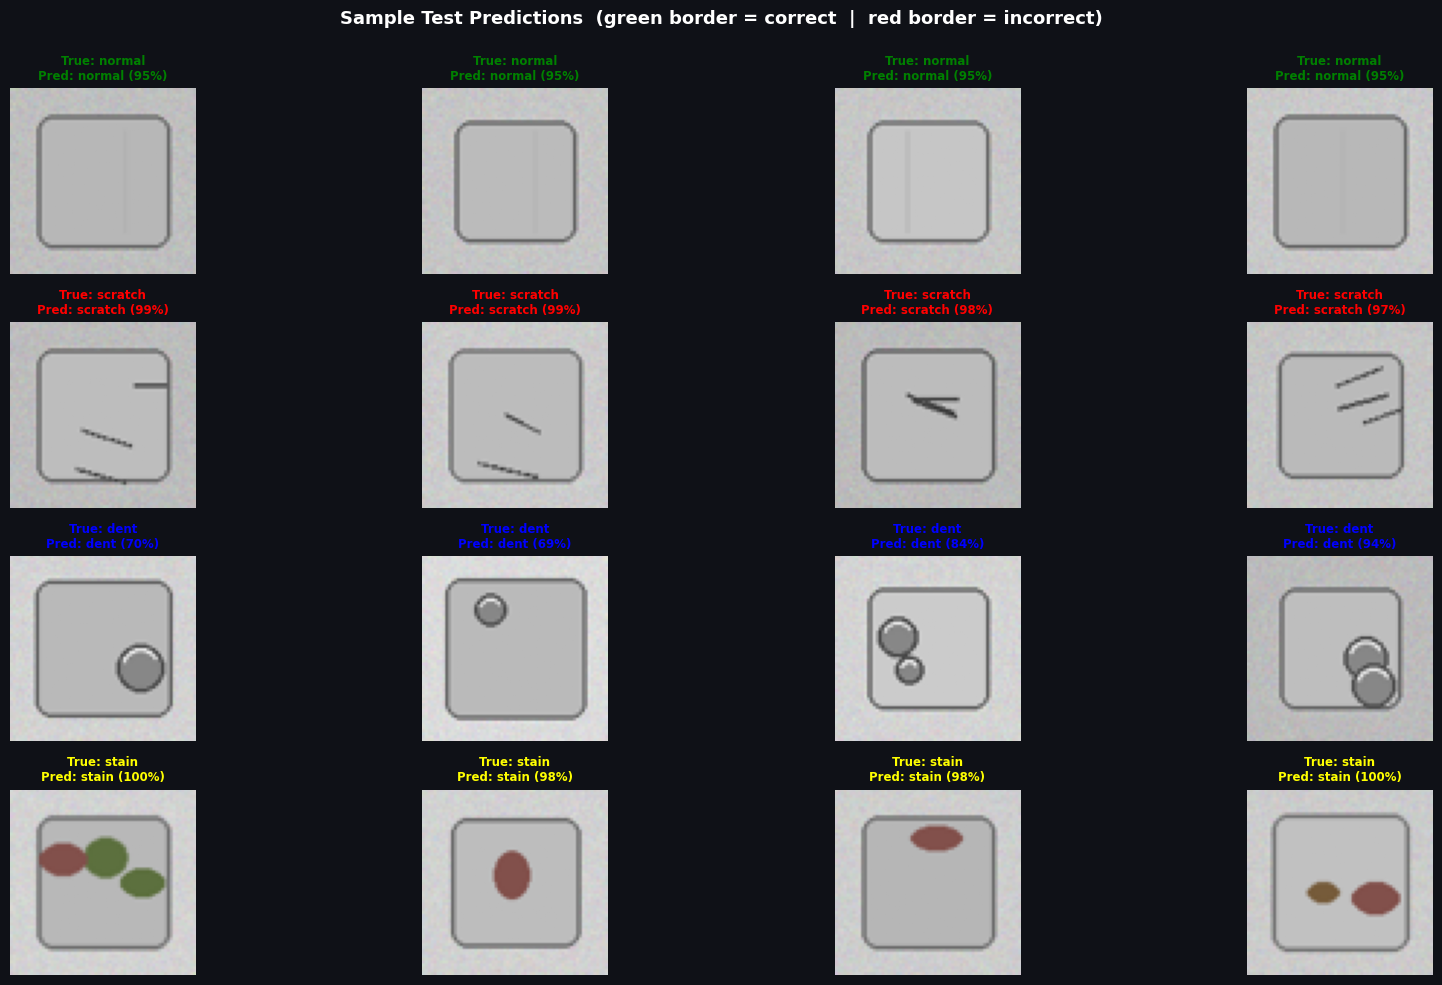

Saved: sample_predictions/prediction_outputs.png


In [11]:
# ── Sample Predictions ───────────────────────────────────────────────────────
# Create output folders
os.makedirs('sample_predictions', exist_ok=True)
os.makedirs('results', exist_ok=True)

print("Folders ready!")

fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor('#0f1117')
fig.text(0.5, 0.98,
         'Sample Test Predictions  (green border = correct  |  red border = incorrect)',
         ha='center', va='top', fontsize=13, fontweight='bold', color='white')

for ci in range(4):
    for j, idx in enumerate(np.where(y_test == ci)[0][:4]):
        ax = fig.add_subplot(4, 4, ci*4+j+1)
        ax.imshow(X_test[idx]); ax.axis('off')
        tc   = CLASSES[y_test[idx]]
        pc   = CLASSES[y_pred[idx]]
        conf = y_prob[idx][y_pred[idx]] * 100
        correct = (y_test[idx] == y_pred[idx])
        ax.set_title(f'True: {tc}\nPred: {pc} ({conf:.0f}%)',
                     fontsize=8.5, color=CLASS_COLORS[pc], fontweight='bold')
        for sp in ax.spines.values():
            sp.set_edgecolor('red' if correct else 'red'); sp.set_linewidth(3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('sample_predictions/prediction_outputs.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("Saved: sample_predictions/prediction_outputs.png")

# Task 6: CNN Concept Explanation

**What is Convolution?**

A small window of size 3×3 is moved across the image, step by step. At each position, the pixels under that window are looked at and checked for a specific pattern. This process is repeated across the whole image and the results are saved in something called a feature map, which shows where that pattern was found.
The interesting part is that the model is not told what patterns to look for. It figures that out on its own during training. In the beginning, simple things like edges and lines are picked up. In the later layers, more detailed things like the shape of a scratch or a dent are recognised.

**Why is Pooling Used?**

After convolution, the amount of data becomes very large. Pooling is used to make it smaller. In MaxPooling, the image is divided into small 2×2 blocks and only the largest value from each block is kept. So a 64×64 image becomes 32×32, half the size.
This also helps the model in another way. If a defect moves slightly in the image, the result stays mostly the same. So the model can still recognise the defect even if it appears in a slightly different position.

**Why is ReLU Used?**

After each convolution step, ReLU is applied. It does one simple thing, any negative number is changed to zero, and positive numbers are kept as they are.
This is needed because without it, the model can only learn very simple straight-line patterns no matter how many layers are added. ReLU allows the model to learn curves, shapes, and complex patterns like defects.
Older methods like sigmoid were tried before but they caused a problem where the model stopped learning in deep networks. ReLU does not have this problem, so training is faster and works better.

**Why CNNs are Better than Regular Networks for Images?**

In a regular network, the image is converted into a long list of numbers and each pixel is treated separately. The connection between neighbouring pixels is completely lost. This requires a very large number of calculations and the model does not understand the structure of the image at all.
In a CNN, a small filter is applied to one small area of the image at a time. This matches how images actually work, a scratch or a dent exists in one area, not spread across the whole image. The same filter is also reused across the entire image, so far fewer calculations are needed.
Because of this, CNNs understand images much better and work far more efficiently, which is why they are used for tasks like detecting defects on product surfaces.

# Task 7: Business Use Case — Manufacturing Quality Inspection

**Domain:** Manufacturing / Industrial Quality Control

**The Problem:**

In a factory, every product needs to be checked for defects before it is packed and shipped. When this is done by human inspectors, it is slow, tiring, and not always consistent — one inspector might pass a part that another would reject. At high production speeds, humans simply cannot keep up.

**How CNN Solves This:**

A camera is placed on the production line. As each part passes by, a photo is taken and instantly sent to the CNN model. Within milliseconds, the model decides whether the part is normal or defective. If a defect is found, the part is automatically removed from the line. If it is fine, it moves forward to packaging. The whole thing happens without any human involvement.

**Why This is Good for Business:**

1) The line never has to slow down for inspection
2) Every single part is checked, not just a random sample
3) The model works the same way at 6am and at midnight — no fatigue, no bad days
4) Defect data is recorded automatically, which helps the factory find and fix the root cause of problems over time

**Where This is Already Being Used:**

This kind of system is used in car manufacturing, electronics, medicine tablet production, and steel factories — anywhere that quality control needs to be fast, accurate, and reliable.